In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["RB", "I", "SM", "SF", "HC", "SS", "J", "JM"] # WR 成交量过低，剔除

In [4]:
def bar_count(time_lst):
    if time_lst == ['09:00-11:30', '13:30-15:00', '21:00-23:00']:
        return 345
    if time_lst == ['09:00-11:30', '13:30-15:00']:
        return 225
    if time_lst == ['09:00-11:30', '13:30-15:00', '21:00-01:00']:
        return 465
    print("......wrong......")

In [5]:
init_money_lst = []
bar_dict = {}

for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  品种交易时间： {info["trading_hours"]}")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")
    bar_dict[symbol] = bar_count(info["trading_hours"])

    init_money_lst.append(int(margin / 0.4))


品种: RB (螺纹钢)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-08
  95分位数价格: 3238.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 22,666.00
  40%保证金所需本金: 56,665 
  分均持仓量: 1,866,543
  分均成交量: 3,777
  分均成交额: 117,764,234

品种: I (铁矿石)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-02
  95分位数价格: 809.00
  合约乘数: 100
  保证金率: 11.00%
  10手保证金: 88,990.00
  40%保证金所需本金: 222,475 
  分均持仓量: 553,491
  分均成交量: 942
  分均成交额: 71,582,174

品种: SM (锰硅)
  品种交易时间： ['09:00-11:30', '13:30-15:00']
  首个交易日: 2021-02-01
  95分位数价格: 6152.00
  合约乘数: 5
  保证金率: 9.00%
  10手保证金: 27,684.00
  40%保证金所需本金: 69,210 
  分均持仓量: 355,431
  分均成交量: 1,014
  分均成交额: 29,761,470

品种: SF (硅铁)
  品种交易时间： ['09:00-11:30', '13:30-15:00']
  首个交易日: 2021-02-01
  95分位数价格: 6016.00
  合约乘数: 5
  保证金率: 8.00%
  10手保证金: 24,064.00
  40%保证金所需本金: 60,160 
  分均持仓量: 201,995
  分均成交量: 843
  分均成交额: 23,724,424

品种: HC (热轧卷板)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-08
  95分位数价格: 3431.00
  合约乘数: 10
 

In [6]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'RB': 56665,
 'I': 222475,
 'SM': 69210,
 'SF': 60160,
 'HC': 60042,
 'SS': 124993,
 'J': 881500,
 'JM': 225810}

In [7]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'RB': 88, 'I': 22, 'SM': 72, 'SF': 83, 'HC': 83, 'SS': 40, 'J': 5, 'JM': 22}

In [8]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5)
train_end_date = '2025-01-01'

In [9]:
from matplotlib.pyplot import bar


def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    day = day * bar_dict[symbol]

    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [10]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00']
trading_hours ['09:00-11:30', '13:30-15:00']


 52%|█████▏    | 32760/63448 [01:31<02:27, 208.18it/s]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


 57%|█████▋    | 36164/63448 [01:49<01:34, 287.74it/s]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


...

 84%|████████▍ | 53208/63448 [02:27<00:20, 504.60it/s]t/s]]

使用的交易价格 tick6t60avg


 96%|█████████▌| 60831/63448 [02:43<00:05, 448.73it/s]2it/s]

使用的交易价格 tick6t60avg


100%|██████████| 128745/128745 [04:49<00:00, 444.05it/s]


In [11]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        # df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-20]

In [18]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
# merged_df_all

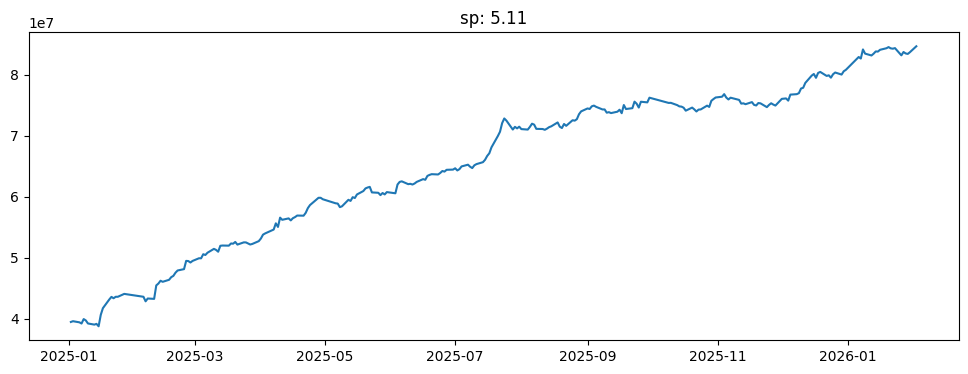

In [19]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

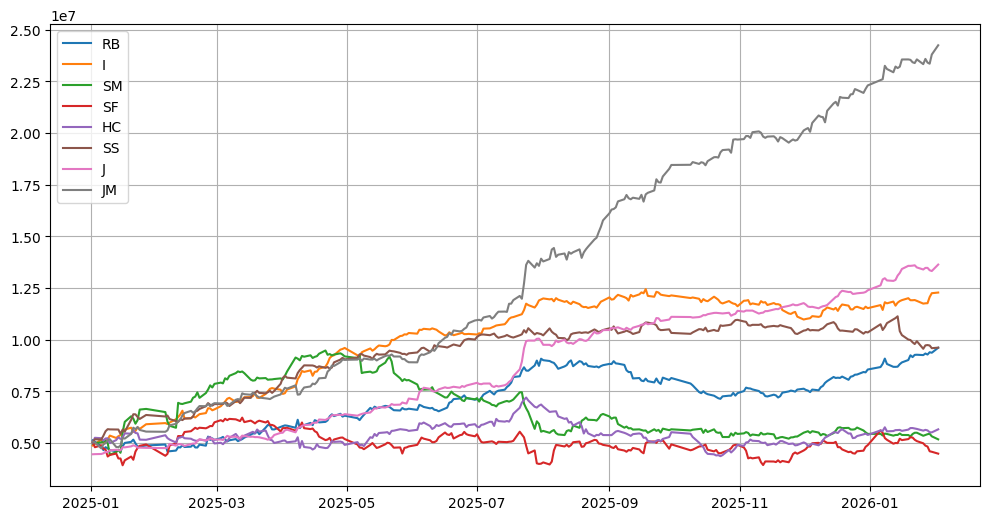

In [20]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [21]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,RB,I,SM,SF,HC,SS,J,JM
多头(+1) 数量,19663,20306,14107,11922,21226,25717,19704,19006
空头(-1) 数量,18769,19185,12549,13874,18755,28198,19069,20993
空仓(0) 数量,57518,57128,36794,37654,55969,74832,57846,56620
多头占比,20.49%,21.02%,22.23%,18.79%,22.12%,19.97%,20.39%,19.67%
空头占比,19.56%,19.86%,19.78%,21.87%,19.55%,21.90%,19.74%,21.73%
空仓占比,59.95%,59.13%,57.99%,59.34%,58.33%,58.12%,59.87%,58.60%
交易日数量,283,284,282,282,283,283,284,284
总收益(非年化%),90.93,173.02,18.69,-13.62,14.51,112.54,198.36,376.93
总交易次数（开平算一次）,2417,3334,2574,2001,2176,3860,3110,3771
日均交易次数（开平算一次）,8.54,11.74,9.13,7.10,7.69,13.64,10.95,13.28
